# ***`Plant Disease Classifier Project`***

## Setup: Environment & Data

Runs on Google Colab with a T4 GPU. Expects the preprocessed dataset package produced locally (`plant_insight_data.zip`: class-grouped images, `manifest_split.csv` with the leak-safe 70/15/15 split, and the `configs/` folder) already uploaded to `Google Drive/PlantInsight/`. The cells below mount Drive and extract that package before training.

In [2]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -q '/content/drive/MyDrive/PlantInsight/plant_insight_data.zip' -d /content/plant_data

In [4]:
!ls /content/plant_data

color  configs	manifest_split.csv


In [5]:
import os
import json
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
import matplotlib.pyplot as plt

DATA_DIR = "/content/plant_data"
CONFIG_DIR = f"{DATA_DIR}/configs"

with open(f"{CONFIG_DIR}/preprocessing.json") as f:
    prep_config = json.load(f)
with open(f"{CONFIG_DIR}/class_weights.json") as f:
    class_weights_dict = json.load(f)
with open(f"{CONFIG_DIR}/class_mapping.json") as f:
    class_mapping = json.load(f)

target_classes = sorted(list(set(class_mapping.values())))
class_to_idx = {cls: idx for idx, cls in enumerate(target_classes)}
class_weights = {class_to_idx[k]: v for k, v in class_weights_dict.items()}

print(f"Total target classes: {len(target_classes)}")


Total target classes: 34


In [6]:
df = pd.read_csv(f"{DATA_DIR}/manifest_split.csv")

# Adapt paths to the unzipped Colab hierarchy
df['rel_path'] = df['rel_path'].str.replace('raw/color/', 'color/')
df['full_path'] = df['rel_path'].apply(lambda p: os.path.join(DATA_DIR, p))

df['target_class'] = df['class_name'].map(class_mapping)
df['class_idx'] = df['target_class'].map(class_to_idx)

sample_path = df.iloc[0]['full_path']
assert os.path.exists(sample_path), f"ERROR: File not found -> {sample_path}"
print("File paths verified successfully.")


File paths verified successfully.


In [10]:
IMG_SIZE = (prep_config['input_height'], prep_config['input_width'])
BATCH_SIZE = 32

def parse_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=prep_config['channels'])

    if prep_config['resize_method'] == 'bilinear':
        img = tf.image.resize(img, IMG_SIZE, method='bilinear')

    return img, label

def create_dataset(split_name, shuffle=False):
    split_df = df[df['final_split'] == split_name]
    paths = split_df['full_path'].values
    labels = split_df['class_idx'].values

    labels = tf.keras.utils.to_categorical(labels, num_classes=len(target_classes))

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)

    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset('train', shuffle=True)
val_ds = create_dataset('val', shuffle=False)
test_ds = create_dataset('test', shuffle=False)
print("Datasets created successfully.")


Datasets created successfully.


## MobileNetV3Small Baseline

First candidate: MobileNetV3Small with a frozen, ImageNet-pretrained backbone, training only the classification head. This is the mobile-friendly baseline that EfficientNetB0 is compared against.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.042),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

base_model = applications.MobileNetV3Small(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(target_classes), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 34)             │        19,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,738 (3.66 MB)

 Trainable params: 19,618 (76.63 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stop_cb = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, early_stop_cb]
)


Starting training...
Epoch 1/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9314 - loss: 0.2515
Epoch 1: val_loss improved from None to 0.20853, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 58s 48ms/step - accuracy: 0.9338 - loss: 0.2403 - val_accuracy: 0.9389 - val_loss: 0.2085
Epoch 2/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9374 - loss: 0.2164
Epoch 2: val_loss improved from 0.20853 to 0.18671, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9389 - loss: 0.2140 - val_accuracy: 0.9395 - val_loss: 0.1867
Epoch 3/15
1185/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9433 - loss: 0.

Evaluating BASELINE MobileNetV3Small on test set...

259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step

🏆 BASELINE MODEL METRICS
{
  "top1_accuracy": 0.949,
  "top3_accuracy": 0.9947,
  "precision_weighted": 0.9519,
  "recall_weighted": 0.949,
  "f1_weighted": 0.9493
}

📊 Training Graph (1-12 Epochs):


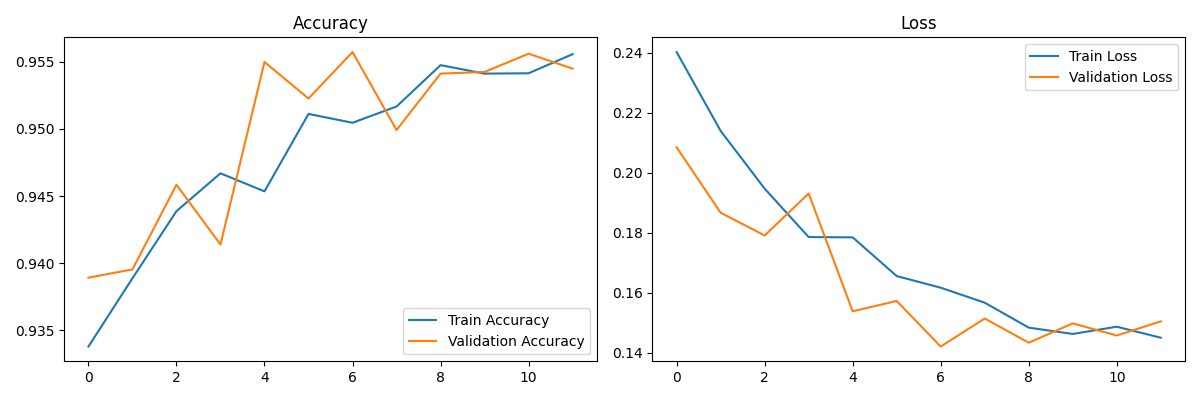

In [ ]:
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score
from IPython.display import Image, display

model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras")

print("Evaluating BASELINE MobileNetV3Small on test set...\n")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds, verbose=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "recall_weighted": round(float(recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "f1_weighted": round(float(f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4)
}

metrics_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("\n🏆 BASELINE MODEL METRICS")
print(json.dumps(metrics, indent=2))

print("\n📊 Training Graph (1-12 Epochs):")
display(Image(filename="/content/drive/MyDrive/PlantInsight/training_graph.png", width=1000))


In [ ]:
checkpoint_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
model = tf.keras.models.load_model(checkpoint_path)
print("Model loaded from checkpoint.")

Model loaded from checkpoint.


In [ ]:
print("Evaluating on test set...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

precision = precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
recall = recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)

precision_macro = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
recall_macro = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision), 4),
    "recall_weighted": round(float(recall), 4),
    "f1_weighted": round(float(f1), 4),
    "precision_macro": round(float(precision_macro), 4),
    "recall_macro": round(float(recall_macro), 4),
    "f1_macro": round(float(f1_macro), 4),
}

metrics_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

Evaluating on test set...
259/259 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step
{
  "top1_accuracy": 0.949,
  "top3_accuracy": 0.9947,
  "precision_weighted": 0.9519,
  "recall_weighted": 0.949,
  "f1_weighted": 0.9493,
  "precision_macro": 0.9288,
  "recall_macro": 0.9445,
  "f1_macro": 0.9343
}


## EfficientNetB0 Baseline

**Architecture substitution note:** the plan called for EfficientNet-Lite0, which is purpose-built for mobile/TFLite quantization. Two independent Keras 3-compatible implementations were tried and both failed with the same root cause (`keras.utils.layer_utils` was removed in Keras 3). EfficientNetB0 is substituted instead, documented here rather than swapped silently. Risk to track: EfficientNetB0's swish activations and squeeze-and-excite blocks may not quantize as cleanly as Lite0 would have.

In [12]:
# Keras 3 native EfficientNetB0 (no external package, no version downgrade needed)
import time
from tensorflow.keras import layers, models, applications

base_model = applications.EfficientNetB0(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
    # No include_preprocessing arg here; the backbone rescales raw [0,255] input internally.
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(target_classes), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │        43,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,093,125 (15.61 MB)

 Trainable params: 43,554 (170.13 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stop_cb = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Starting training EfficientNetB0...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, early_stop_cb]
)


Starting training EfficientNetB0...
Epoch 1/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7362 - loss: 1.3102
Epoch 1: val_loss improved from None to 0.31114, saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 143s 107ms/step - accuracy: 0.8514 - loss: 0.7451 - val_accuracy: 0.9207 - val_loss: 0.3111
Epoch 2/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9239 - loss: 0.3138
Epoch 2: val_loss improved from 0.31114 to 0.20531, saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 119s 100ms/step - accuracy: 0.9313 - loss: 0.2849 - val_accuracy: 0.9441 - val_loss: 0.2053
Epoch 3/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9465

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import os
import numpy as np
import tensorflow as tf
import pandas as pd

# Reload explicitly from disk rather than trusting the in-memory object left
# over from model.fit() -- this is what fixes the Keras 3 stale-state issue.
checkpoint_path = "/content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras"
model = tf.keras.models.load_model(checkpoint_path)

print("Evaluating EfficientNetB0 on test set...")
y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "recall_weighted": round(float(recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "f1_weighted": round(float(f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
}

print("Benchmarking CPU inference speed...")
dummy_input = tf.random.uniform((1, 224, 224, 3))
for _ in range(10):  # warm-up
    model(dummy_input, training=False)

start_time = time.time()
for _ in range(100):
    model(dummy_input, training=False)
end_time = time.time()
inference_time_ms = ((end_time - start_time) / 100) * 1000
metrics["inference_time_ms"] = round(inference_time_ms, 2)

model_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
metrics["model_size_mb"] = round(model_size_mb, 2)

metrics_path = "/content/drive/MyDrive/PlantInsight/efficientnetb0_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("\n--- EfficientNetB0 Metrics ---")
print(json.dumps(metrics, indent=2))

print("\nGenerating model_comparison.csv...")
with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_metrics = json.load(f)

mb_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
mb_size_mb = os.path.getsize(mb_path) / (1024 * 1024) if os.path.exists(mb_path) else "N/A"

comparison_df = pd.DataFrame([
    {
        "Model": "MobileNetV3Small",
        "Top-1 Acc": mb_metrics["top1_accuracy"],
        "F1-Macro": mb_metrics["f1_macro"],
        "Model Size (MB)": round(mb_size_mb, 2) if isinstance(mb_size_mb, float) else mb_size_mb,
        "Inference (ms)": mb_metrics.get("inference_time_ms", "N/A (Skipped in Day3)")
    },
    {
        "Model": "EfficientNetB0",
        "Top-1 Acc": metrics["top1_accuracy"],
        "F1-Macro": metrics["f1_macro"],
        "Model Size (MB)": metrics["model_size_mb"],
        "Inference (ms)": metrics["inference_time_ms"]
    }
])

comparison_csv = "/content/drive/MyDrive/PlantInsight/model_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

print(f"\nSaved comparison to: {comparison_csv}")
print("\n--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))


Evaluating EfficientNetB0 on test set...
259/259 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step
Benchmarking CPU Inference Speed...

--- EfficientNetB0 Metrics ---
{
  "top1_accuracy": 0.9657,
  "top3_accuracy": 0.9966,
  "precision_weighted": 0.9676,
  "recall_weighted": 0.9657,
  "f1_weighted": 0.9659,
  "precision_macro": 0.9606,
  "recall_macro": 0.9578,
  "f1_macro": 0.9583,
  "inference_time_ms": 322.21,
  "model_size_mb": 16.77
}

Generating model_comparison.csv...

Saved comparison to: /content/drive/MyDrive/PlantInsight/model_comparison.csv

--- Final Model Comparison ---
           Model  Top-1 Acc  F1-Macro  Model Size (MB)  Inference (ms)
MobileNetV3Small     0.9490    0.9343             4.36          175.16
  EfficientNetB0     0.9657    0.9583            16.77          322.21


In [ ]:
import time

mobilenet_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
mobilenet_model = tf.keras.models.load_model(mobilenet_path)

dummy_input = tf.random.uniform((1, 224, 224, 3))
for _ in range(10):
    mobilenet_model(dummy_input, training=False)

start_time = time.time()
for _ in range(100):
    mobilenet_model(dummy_input, training=False)
end_time = time.time()
mobilenet_inference_ms = ((end_time - start_time) / 100) * 1000

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_metrics = json.load(f)

mb_metrics["inference_time_ms"] = round(mobilenet_inference_ms, 2)
mb_metrics["model_size_mb"] = round(os.path.getsize(mobilenet_path) / (1024 * 1024), 2)

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json", "w") as f:
    json.dump(mb_metrics, f, indent=2)

print(json.dumps(mb_metrics, indent=2))

{
  "top1_accuracy": 0.949,
  "top3_accuracy": 0.9947,
  "precision_weighted": 0.9519,
  "recall_weighted": 0.949,
  "f1_weighted": 0.9493,
  "precision_macro": 0.9288,
  "recall_macro": 0.9445,
  "f1_macro": 0.9343,
  "inference_time_ms": 158.17,
  "model_size_mb": 4.36
}


In [ ]:
import json
import os
import pandas as pd

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_metrics = json.load(f)

with open("/content/drive/MyDrive/PlantInsight/efficientnetb0_metrics.json") as f:
    eff_metrics = json.load(f)

comparison_df = pd.DataFrame([
    {
        "Model": "MobileNetV3Small",
        "Top-1 Acc": mb_metrics["top1_accuracy"],
        "F1-Macro": mb_metrics["f1_macro"],
        "Model Size (MB)": mb_metrics["model_size_mb"],
        "Inference (ms)": mb_metrics["inference_time_ms"],
    },
    {
        "Model": "EfficientNetB0",
        "Top-1 Acc": eff_metrics["top1_accuracy"],
        "F1-Macro": eff_metrics["f1_macro"],
        "Model Size (MB)": eff_metrics["model_size_mb"],
        "Inference (ms)": eff_metrics["inference_time_ms"],
    },
])

comparison_csv = "/content/drive/MyDrive/PlantInsight/model_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

print(f"Saved comparison to: {comparison_csv}")
print("\n--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))

Saved comparison to: /content/drive/MyDrive/PlantInsight/model_comparison.csv

--- Final Model Comparison ---
           Model  Top-1 Acc  F1-Macro  Model Size (MB)  Inference (ms)
MobileNetV3Small     0.9490    0.9343             4.36          175.16
  EfficientNetB0     0.9657    0.9583            16.77          322.21


## Final Model Selection & Fine-Tuning

**Selection rationale:** EfficientNetB0 scores higher on raw accuracy (96.57% vs 94.90% Top-1) and F1-macro (0.9583 vs 0.9343), but MobileNetV3Small is ~3.8x smaller (4.36MB vs 16.77MB) and faster (175ms vs 322ms, same CPU benchmark). Since the final deliverable is an on-device mobile app, MobileNetV3Small is selected and fine-tuned below to close part of the accuracy gap.

### Inspecting the Backbone

Before fine-tuning, the backbone's internal layer structure is inspected directly rather than guessed, to decide exactly which blocks to unfreeze and to correctly locate BatchNormalization layers. BN layers are deliberately kept frozen during fine-tuning, following standard guidance for small or class-imbalanced batches.

In [13]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
)

for layer in model.layers:
    print(layer.name, "-", layer.__class__.__name__)

input_layer_1 - InputLayer
data_augmentation - Sequential
MobileNetV3Small - Functional
global_average_pooling2d - GlobalAveragePooling2D
dropout - Dropout
dense - Dense


In [14]:
backbone = model.get_layer("MobileNetV3Small")
print("Total layers in backbone:", len(backbone.layers))

print("\nLast 25 layers:")
for layer in backbone.layers[-25:]:
    print(layer.name, "-", layer.__class__.__name__)

Total layers in backbone: 157

Last 25 layers:
expanded_conv_9_squeeze_excite_relu - ReLU
expanded_conv_9_squeeze_excite_conv_1 - Conv2D
re_lu_12 - ReLU
expanded_conv_9_squeeze_excite_mul - Multiply
expanded_conv_9_project - Conv2D
expanded_conv_9_project_bn - BatchNormalization
expanded_conv_9_add - Add
expanded_conv_10_expand - Conv2D
expanded_conv_10_expand_bn - BatchNormalization
activation_15 - Activation
expanded_conv_10_depthwise - DepthwiseConv2D
expanded_conv_10_depthwise_bn - BatchNormalization
activation_16 - Activation
expanded_conv_10_squeeze_excite_avg_pool - GlobalAveragePooling2D
expanded_conv_10_squeeze_excite_conv - Conv2D
expanded_conv_10_squeeze_excite_relu - ReLU
expanded_conv_10_squeeze_excite_conv_1 - Conv2D
re_lu_13 - ReLU
expanded_conv_10_squeeze_excite_mul - Multiply
expanded_conv_10_project - Conv2D
expanded_conv_10_project_bn - BatchNormalization
expanded_conv_10_add - Add
conv_1 - Conv2D
conv_1_bn - BatchNormalization
activation_17 - Activation


In [15]:
for i, layer in enumerate(backbone.layers):
    if "_project" in layer.name and "bn" not in layer.name:
        print(i, layer.name)

print("\nTotal layers:", len(backbone.layers))

15 expanded_conv_project
24 expanded_conv_1_project
32 expanded_conv_2_project
48 expanded_conv_3_project
62 expanded_conv_4_project
77 expanded_conv_5_project
92 expanded_conv_6_project
106 expanded_conv_7_project
122 expanded_conv_8_project
136 expanded_conv_9_project
151 expanded_conv_10_project

Total layers: 157


In [16]:
UNFREEZE_FROM_INDEX = 123

backbone.trainable = True

for i, layer in enumerate(backbone.layers):
    if i < UNFREEZE_FROM_INDEX:
        layer.trainable = False
    elif isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_backbone_layers = sum(1 for l in backbone.layers if l.trainable)
print(f"Trainable layers in backbone: {trainable_backbone_layers} / {len(backbone.layers)}")

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Trainable parameters: {trainable_params:,}")

Trainable layers in backbone: 26 / 157
Trainable parameters: 658,114


### Fine-Tuning

Blocks 9-10 (the last ~18% of the backbone) and the final conv layers are unfrozen; BatchNorm layers stay frozen. Recompiled with a much lower learning rate (1e-5), appropriate for adjusting pretrained weights rather than training from scratch.

In [ ]:
from tensorflow.keras import callbacks

# Recompile with a much smaller learning rate now that backbone layers are unfrozen
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_path_ft = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
checkpoint_cb_ft = callbacks.ModelCheckpoint(
    filepath=checkpoint_path_ft,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stop_cb_ft = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Starting fine-tuning for MobileNetV3Small (blocks 9 & 10)...")
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint_cb_ft, early_stop_cb_ft]
)


Starting FINE-TUNING for MobileNetV3Small (Blocks 9 & 10)...
Epoch 1/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9590 - loss: 0.1340
Epoch 1: val_loss improved from None to 0.13768, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 1141s 947ms/step - accuracy: 0.9611 - loss: 0.1289 - val_accuracy: 0.9573 - val_loss: 0.1377
Epoch 2/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.9628 - loss: 0.1202
Epoch 2: val_loss improved from 0.13768 to 0.12423, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 1138s 959ms/step - accuracy: 0.9645 - loss: 0.1158 - val_accuracy: 0.9614 - val_loss: 0.1242
Epoch 3/10
1186/1186 ━━━━━━━━━━━

KeyboardInterrupt: 

### Debugging: Confirming GPU Availability

Fine-tuning was unexpectedly ~20x slower per step than the baseline model (947ms/step vs 46ms/step) after a Colab runtime reconnect. This cell confirms whether the runtime is still GPU-backed before resuming training.

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Resuming After Interruption

The fine-tuning run above was manually interrupted after epoch 5. This cell reloads the checkpoint and re-verifies that the exact same layers are trainable as before (26 layers, 658,114 parameters) before resuming, so the interruption cannot silently change what is being trained.

In [ ]:
import tensorflow as tf
from tensorflow.keras import callbacks

# Reload from the Drive checkpoint; .keras format also restores optimizer state
model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras")

trainable_backbone_layers = sum(1 for l in model.get_layer("MobileNetV3Small").layers if l.trainable)
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Trainable backbone layers: {trainable_backbone_layers} (expected: 26)")
print(f"Trainable parameters: {trainable_params:,} (expected: 658,114)")

checkpoint_path_ft = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
checkpoint_cb_ft = callbacks.ModelCheckpoint(
    filepath=checkpoint_path_ft,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)
early_stop_cb_ft = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Resuming fine-tuning for the remaining epochs...")
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=5,  # training was interrupted after epoch 5
    epochs=10,        # only epochs 6-10 actually run given initial_epoch=5
    class_weight=class_weights,
    callbacks=[checkpoint_cb_ft, early_stop_cb_ft]
)


Trainable backbone layers: 27 (expected: 26)
Trainable parameters: 658,114 (expected: 658,114)
Resuming FINE-TUNING for remaining 5 epochs...
Epoch 6/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9724 - loss: 0.0919
Epoch 6: val_loss improved from None to 0.10900, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras

Epoch 6: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 67s 52ms/step - accuracy: 0.9727 - loss: 0.0897 - val_accuracy: 0.9672 - val_loss: 0.1090
Epoch 7/10
1185/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9746 - loss: 0.0800
Epoch 7: val_loss did not improve from 0.10900
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - accuracy: 0.9740 - loss: 0.0819 - val_accuracy: 0.9680 - val_loss: 0.1095
Epoch 8/10
1185/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9738 - loss: 0.0796
Epoch 8: val_loss improved from 0.10900 to 0.10463, saving model

### Final Evaluation

Reloads the best fine-tuned checkpoint from disk and evaluates it on the untouched test split.

In [ ]:
import tensorflow as tf

# Reload the best checkpoint explicitly rather than relying on in-memory state
model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras")

from sklearn.metrics import precision_score, recall_score, f1_score
import json
import numpy as np
import time
import os

print("Evaluating fine-tuned MobileNetV3Small on test set...")
y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

metrics_ft = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "recall_weighted": round(float(recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "f1_weighted": round(float(f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
}

# CPU inference benchmark, establishes the pre-TFLite reference speed
print("\nBenchmarking CPU inference speed...")
dummy_input = tf.random.uniform((1, 224, 224, 3))
for _ in range(10):  # warm-up
    model(dummy_input, training=False)
start_time = time.time()
for _ in range(100):
    model(dummy_input, training=False)
inference_time_ms = ((time.time() - start_time) / 100) * 1000
metrics_ft["inference_time_ms"] = round(inference_time_ms, 2)

metrics_path_ft = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned_metrics.json"
model_size_mb = os.path.getsize("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras") / (1024 * 1024)
metrics_ft["model_size_mb"] = round(model_size_mb, 2)

with open(metrics_path_ft, "w") as f:
    json.dump(metrics_ft, f, indent=2)

print("\n--- Fine-Tuned MobileNetV3Small Metrics ---")
print(json.dumps(metrics_ft, indent=2))

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_baseline = json.load(f)

print("\n" + "="*40)
print("FINAL RESULTS")
print("="*40)
print(f"Top-1 Accuracy : {mb_baseline['top1_accuracy']:.4f} -> {metrics_ft['top1_accuracy']:.4f}")
print(f"F1-Macro       : {mb_baseline['f1_macro']:.4f} -> {metrics_ft['f1_macro']:.4f}")
print(f"CPU Speed (ms) : N/A -> {metrics_ft['inference_time_ms']} ms")
print("="*40)


Evaluating FINE-TUNED MobileNetV3Small on test set...
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step

Benchmarking CPU Inference Speed...

--- Fine-Tuned MobileNetV3Small Metrics ---
{
  "top1_accuracy": 0.9642,
  "top3_accuracy": 0.9977,
  "precision_weighted": 0.9657,
  "recall_weighted": 0.9642,
  "f1_weighted": 0.9643,
  "precision_macro": 0.9513,
  "recall_macro": 0.9605,
  "f1_macro": 0.9548,
  "inference_time_ms": 213.48,
  "model_size_mb": 9.24
}

🏆 THE FINAL RESULTS (Day 3 vs Day 5)
Top-1 Accuracy : 0.9490 -> 0.9642
F1-Macro       : 0.9343 -> 0.9548
CPU Speed (ms) : N/A -> 213.48 ms


### Confusion Matrix & Per-Class Report

Generating Confusion Matrix for the Fine-Tuned Champion Model...


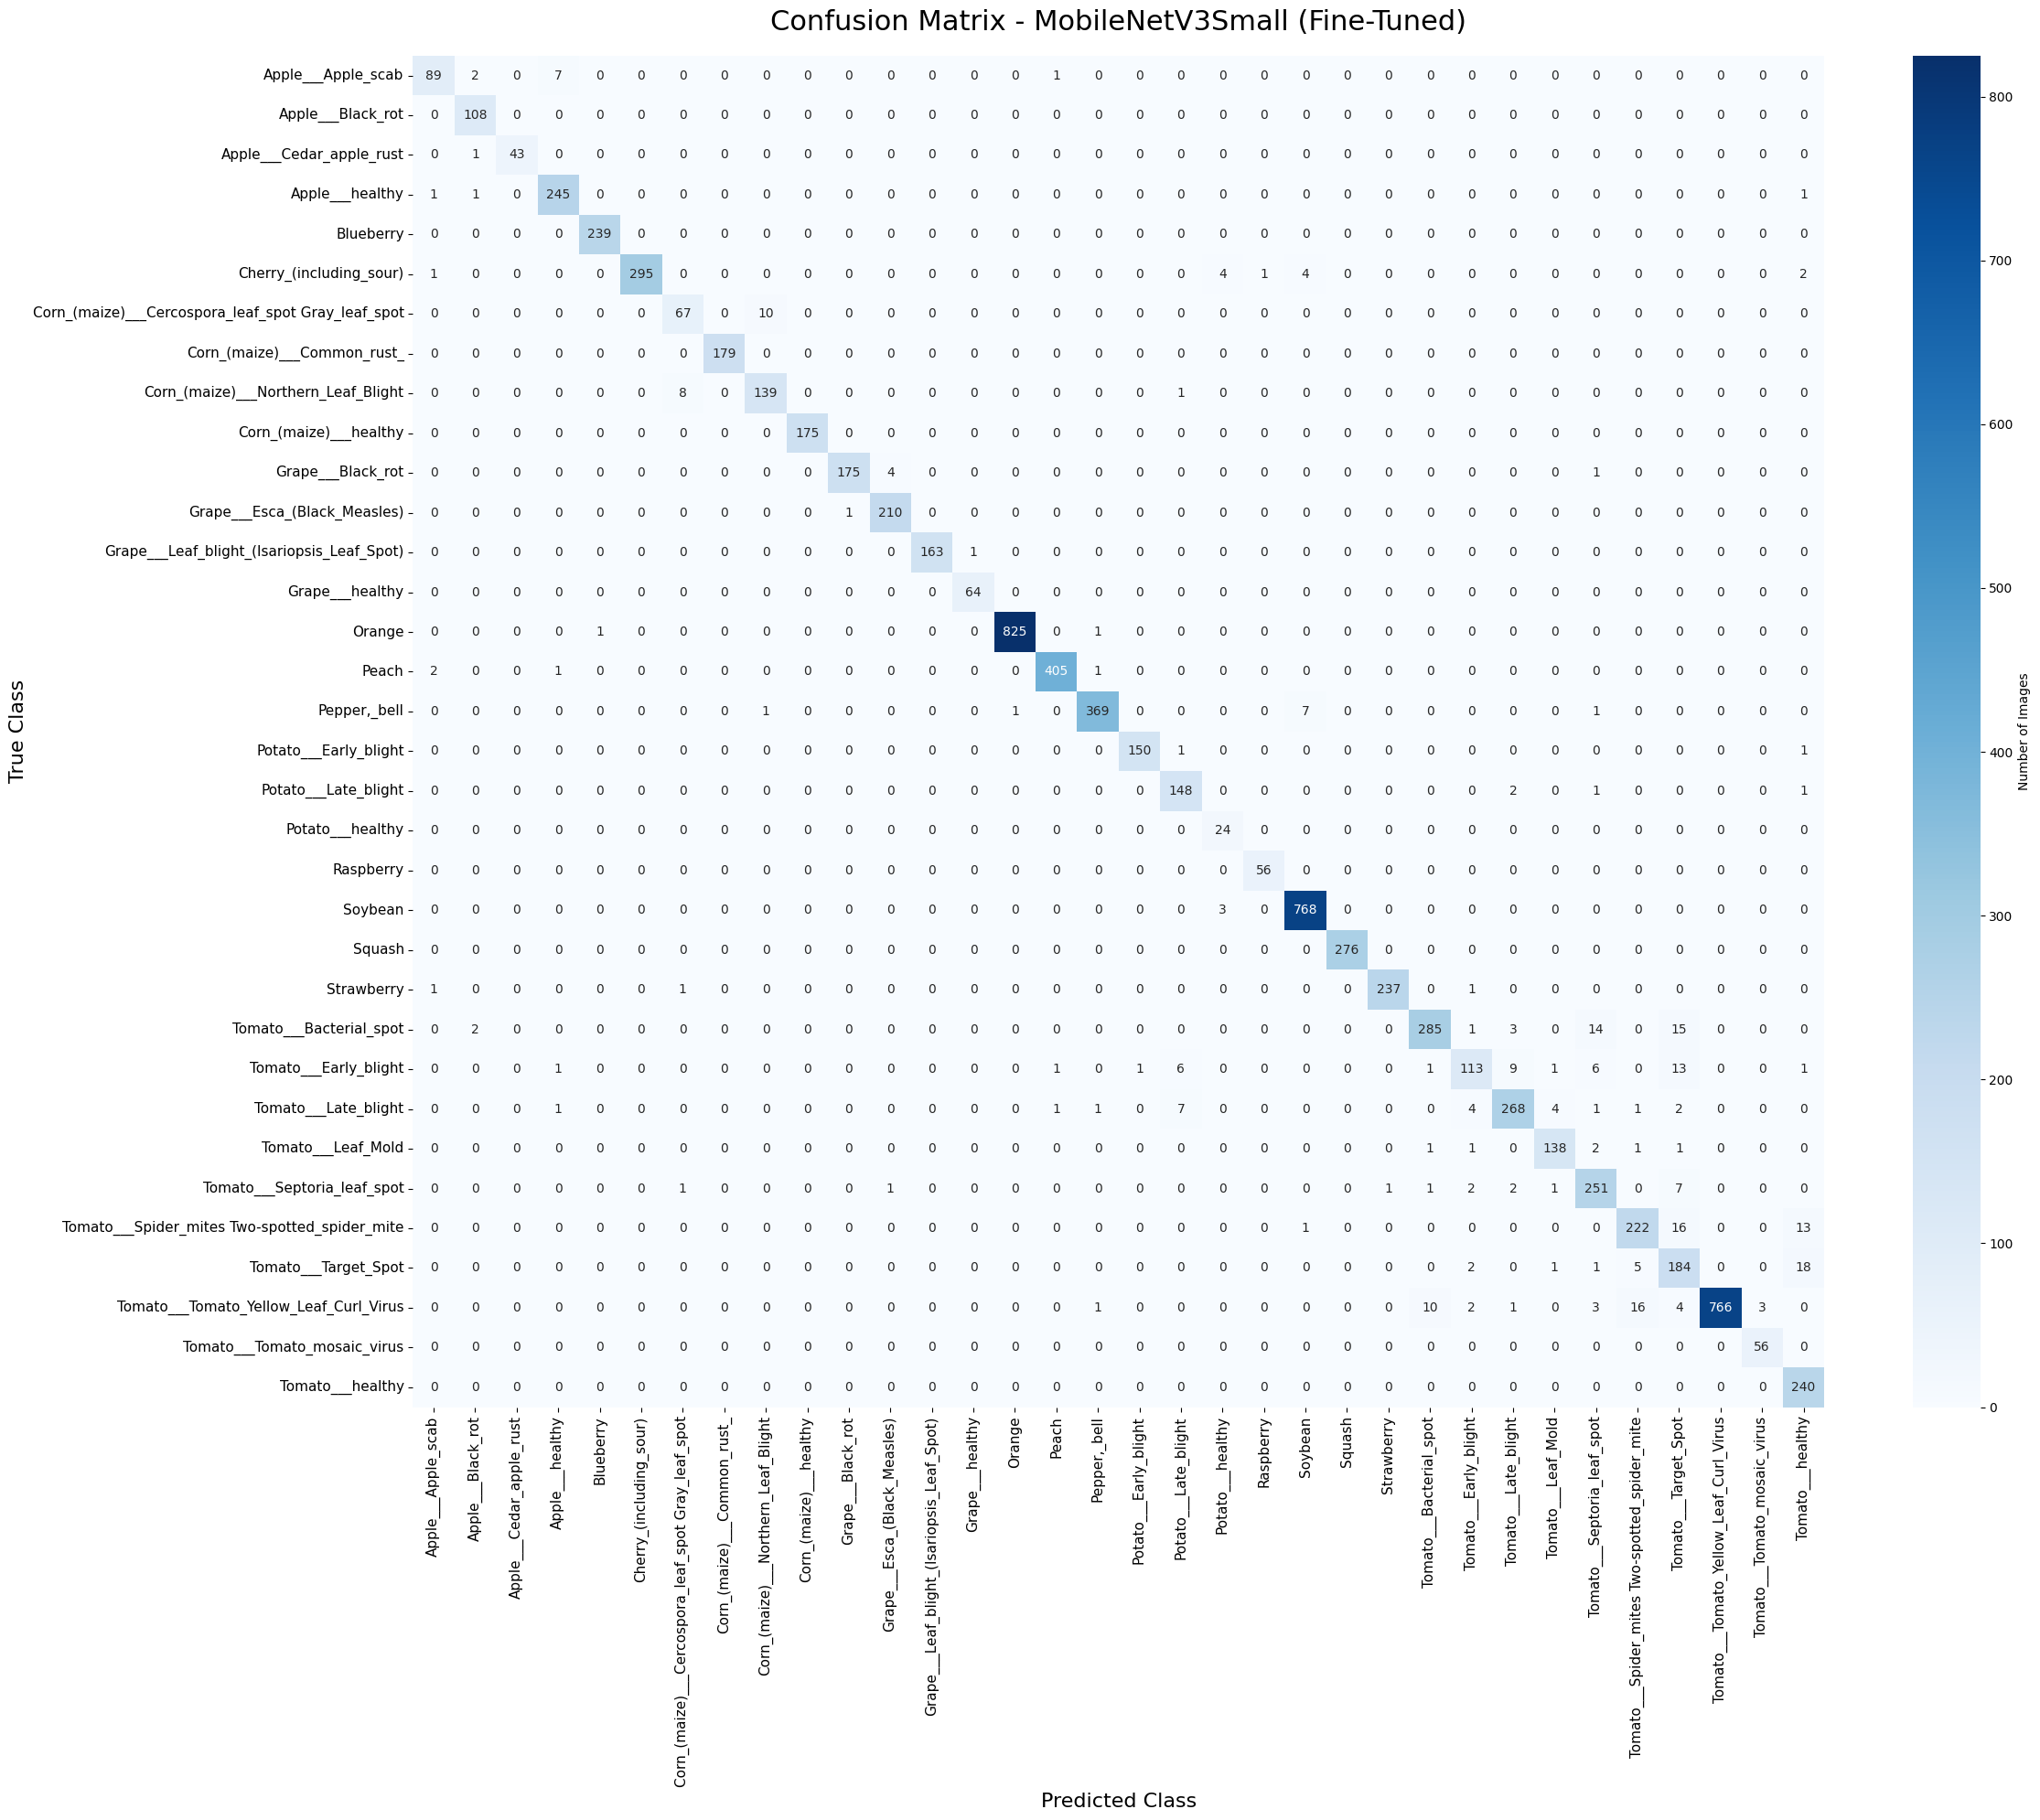

✅ Confusion Matrix başarıyla kaydedildi: /content/drive/MyDrive/PlantInsight/confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating confusion matrix for the fine-tuned model...")

cm = confusion_matrix(y_true_labels, y_pred_labels)

# Large figure size so all 34 classes remain legible
plt.figure(figsize=(24, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes,
            yticklabels=target_classes,
            cbar_kws={'label': 'Number of Images'})

plt.title('Confusion Matrix - MobileNetV3Small (Fine-Tuned)', fontsize=22, pad=20)
plt.ylabel('True Class', fontsize=16)
plt.xlabel('Predicted Class', fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

cm_path = "/content/drive/MyDrive/PlantInsight/confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved: {cm_path}")


In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras")

y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

from sklearn.metrics import classification_report

report = classification_report(
    y_true_labels, y_pred_labels,
    target_names=target_classes,
    digits=4,
    zero_division=0,
)
print(report)

report_path = "/content/drive/MyDrive/PlantInsight/classification_report.txt"
with open(report_path, "w") as f:
    f.write(report)
print(f"Saved: {report_path}")

259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9468    0.8990    0.9223        99
                                 Apple___Black_rot     0.9474    1.0000    0.9730       108
                          Apple___Cedar_apple_rust     1.0000    0.9773    0.9885        44
                                   Apple___healthy     0.9608    0.9879    0.9742       248
                                         Blueberry     0.9958    1.0000    0.9979       239
                           Cherry_(including_sour)     1.0000    0.9609    0.9801       307
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8701    0.8701    0.8701        77
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       179
               Corn_(maize)___Northern_Leaf_Blight     0.9267    0.9392    0.9329       148
                            Corn_(ma

## Export Artifacts

Packages the key reports and metrics for download, to be committed into the local project repository alongside the previous codes pipeline.

In [ ]:
import os
import shutil
from google.colab import files

report_files = [
    "training_graph.png",
    "confusion_matrix.png",
    "classification_report.txt",
    "mobilenetv3small_metrics.json",
    "efficientnetb0_metrics.json",
    "mobilenetv3small_finetuned_metrics.json",
    "model_comparison.csv",
]

os.makedirs("/content/day3_5_artifacts", exist_ok=True)
for fname in report_files:
    src = f"/content/drive/MyDrive/PlantInsight/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"/content/day3_5_artifacts/{fname}")
    else:
        print(f"MISSING: {fname}")

shutil.make_archive("/content/day3_5_artifacts", "zip", "/content/day3_5_artifacts")
files.download("/content/day3_5_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Real-World Evaluation on PlantDoc

In [17]:
import os

os.makedirs("/content/plantdoc_test", exist_ok=True)
!unzip -q '/content/drive/MyDrive/PlantInsight/plantdoc_test.zip' -d /content/plantdoc_test
!ls /content/plantdoc_test/test

 Apple___Apple_scab
 Apple___Cedar_apple_rust
 Blueberry
'Cherry_(including_sour)'
'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
'Corn_(maize)___Common_rust_'
'Corn_(maize)___Northern_Leaf_Blight'
 Grape___Black_rot
 Peach
 Pepper_bell
 Potato___Early_blight
 Potato___Late_blight
 Raspberry
 Soybean
 Squash
 Strawberry
 Tomato___Bacterial_spot
 Tomato___Early_blight
 Tomato___Late_blight
 Tomato___Leaf_Mold
 Tomato___Septoria_leaf_spot
 Tomato___Tomato_mosaic_virus
 Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [18]:
import pandas as pd

plantdoc_df = pd.read_csv("/content/drive/MyDrive/PlantInsight/plantdoc_manifest.csv")
plantdoc_test_df = plantdoc_df[plantdoc_df["official_split"] == "test"].copy()

print("PlantDoc test rows:", len(plantdoc_test_df))
print("Classes in PlantDoc test:", sorted(plantdoc_test_df["target_class"].unique()))

missing_from_target = set(plantdoc_test_df["target_class"].unique()) - set(target_classes)
print("\nClasses in PlantDoc but NOT in our target_classes (should be empty):", missing_from_target)

PlantDoc test rows: 384
Classes in PlantDoc test: ['Apple___Apple_scab', 'Apple___Cedar_apple_rust', 'Blueberry', 'Cherry_(including_sour)', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Peach', 'Pepper,_bell', 'Potato___Early_blight', 'Potato___Late_blight', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus']

Classes in PlantDoc but NOT in our target_classes (should be empty): set()


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json
import ntpath

# Reload explicitly from disk -- do not trust any in-memory model object
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
)

# Build file paths matching the extracted zip layout: /content/plantdoc_test/test/<class>/<file>.jpg
def crop_path_to_extracted_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])  # handles Windows-style backslash paths on Linux
    return f"/content/plantdoc_test/test/{class_folder}/{filename}"

plantdoc_test_df["extracted_path"] = plantdoc_test_df.apply(crop_path_to_extracted_path, axis=1)

sample_path = plantdoc_test_df.iloc[0]["extracted_path"]
assert os.path.exists(sample_path), f"Path check failed: {sample_path}"
print("Path check passed:", sample_path)

plantdoc_test_df["class_idx"] = plantdoc_test_df["target_class"].map(class_to_idx)
assert plantdoc_test_df["class_idx"].isna().sum() == 0, "Some classes failed to map to an index"

def parse_plantdoc_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    return img, label

paths = plantdoc_test_df["extracted_path"].values
labels = tf.keras.utils.to_categorical(plantdoc_test_df["class_idx"].values, num_classes=len(target_classes))

plantdoc_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
plantdoc_ds = plantdoc_ds.map(parse_plantdoc_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_ds = plantdoc_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("Evaluating on PlantDoc test set (real-world images)...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

plantdoc_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "num_test_images": len(plantdoc_test_df),
    "num_classes_evaluated": int(plantdoc_test_df["target_class"].nunique()),
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_before.json", "w") as f:
    json.dump(plantdoc_metrics, f, indent=2)

print("\n--- PlantDoc (Real-World) Test Metrics ---")
print(json.dumps(plantdoc_metrics, indent=2))

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned_metrics.json") as f:
    pv_metrics = json.load(f)

print("\n" + "="*50)
print("DOMAIN GAP: PlantVillage (lab) vs PlantDoc (real-world)")
print("="*50)
print(f"Top-1 Accuracy : {pv_metrics['top1_accuracy']:.4f} -> {plantdoc_metrics['top1_accuracy']:.4f}")
print(f"F1-Macro       : {pv_metrics['f1_macro']:.4f} -> {plantdoc_metrics['f1_macro']:.4f}")
print("="*50)

Path check passed: /content/plantdoc_test/test/Tomato___Tomato_Yellow_Leaf_Curl_Virus/0.jpg
Evaluating on PlantDoc test set (real-world images)...
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step

--- PlantDoc (Real-World) Test Metrics ---
{
  "top1_accuracy": 0.2682,
  "top3_accuracy": 0.474,
  "precision_macro": 0.2073,
  "recall_macro": 0.1885,
  "f1_macro": 0.1681,
  "num_test_images": 384,
  "num_classes_evaluated": 23
}

DOMAIN GAP: PlantVillage (lab) vs PlantDoc (real-world)
Top-1 Accuracy : 0.9642 -> 0.2682
F1-Macro       : 0.9548 -> 0.1681


In [ ]:
from sklearn.metrics import classification_report

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices,
    target_names=evaluated_classes,
    digits=4,
    zero_division=0,
)
print(report)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_classification_report_before.txt", "w") as f:
    f.write(report)
print("Saved: plantdoc_classification_report_before.txt")

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.2222    0.1538    0.1818        13
                          Apple___Cedar_apple_rust     0.0000    0.0000    0.0000        12
                                         Blueberry     0.9091    0.4545    0.6061        22
                           Cherry_(including_sour)     0.5000    0.1579    0.2400        19
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.1176    0.5000    0.1905         4
                       Corn_(maize)___Common_rust_     0.0323    0.0909    0.0476        11
               Corn_(maize)___Northern_Leaf_Blight     0.2222    0.3333    0.2667        12
                                 Grape___Black_rot     0.0000    0.0000    0.0000         8
                                             Peach     0.1250    0.1000    0.1111        10
                                      Pepper,_bell     0.3846    0.3846    0.38

In [19]:
os.makedirs("/content/plantdoc_train_valid", exist_ok=True)
!unzip -q '/content/drive/MyDrive/PlantInsight/plantdoc_train_valid.zip' -d /content/plantdoc_train_valid
!ls /content/plantdoc_train_valid

train  valid


In [20]:
import ntpath

# PlantDoc train -> mixed training; PlantDoc valid -> validation signal (not trained on)
plantdoc_train_only = plantdoc_df[plantdoc_df["official_split"] == "train"].copy()
plantdoc_valid_only = plantdoc_df[plantdoc_df["official_split"] == "valid"].copy()

def plantdoc_to_colab_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])
    return f"/content/plantdoc_train_valid/{row['official_split']}/{class_folder}/{filename}"

for sub_df in (plantdoc_train_only, plantdoc_valid_only):
    sub_df["full_path"] = sub_df.apply(plantdoc_to_colab_path, axis=1)
    sub_df["class_idx"] = sub_df["target_class"].map(class_to_idx)

assert os.path.exists(plantdoc_train_only.iloc[0]["full_path"])
assert os.path.exists(plantdoc_valid_only.iloc[0]["full_path"])
print("Path checks passed.")

assert "test" not in plantdoc_train_only["official_split"].unique()
assert "test" not in plantdoc_valid_only["official_split"].unique()
print("Leakage check passed: PlantDoc test excluded from both training and validation")

pv_train_df = df[df["final_split"] == "train"].copy()
pv_train_df["target_class"] = pv_train_df["class_name"].map(class_mapping)
pv_train_df["class_idx"] = pv_train_df["target_class"].map(class_to_idx)

print(f"\nPlantVillage train: {len(pv_train_df)}")
print(f"PlantDoc train: {len(plantdoc_train_only)}")
print(f"Ratio: {len(pv_train_df) / len(plantdoc_train_only):.1f}:1")
print(f"PlantDoc valid (validation only): {len(plantdoc_valid_only)}")

mixed_paths = np.concatenate([pv_train_df["full_path"].values, plantdoc_train_only["full_path"].values])
mixed_labels = np.concatenate([pv_train_df["class_idx"].values, plantdoc_train_only["class_idx"].values])
print(f"\nMixed training set: {len(mixed_paths)}")

Path checks passed.
Leakage check passed: PlantDoc test excluded from both training and validation

PlantVillage train: 37950
PlantDoc train: 6010
Ratio: 6.3:1
PlantDoc valid (validation only): 951

Mixed training set: 43960


In [24]:
mixed_labels_cat = tf.keras.utils.to_categorical(mixed_labels, num_classes=len(target_classes))

mixed_ds = tf.data.Dataset.from_tensor_slices((mixed_paths, mixed_labels_cat))
mixed_ds = mixed_ds.shuffle(buffer_size=len(mixed_paths), seed=42)
mixed_ds = mixed_ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
mixed_ds = mixed_ds.batch(32).prefetch(tf.data.AUTOTUNE)

pd_valid_labels_cat = tf.keras.utils.to_categorical(
    plantdoc_valid_only["class_idx"].values, num_classes=len(target_classes)
)
plantdoc_valid_ds = tf.data.Dataset.from_tensor_slices(
    (plantdoc_valid_only["full_path"].values, pd_valid_labels_cat)
)
plantdoc_valid_ds = plantdoc_valid_ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_valid_ds = plantdoc_valid_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("Mixed training and PlantDoc validation datasets ready.")

Mixed training and PlantDoc validation datasets ready.


In [25]:
from collections import Counter

mixed_counts = Counter(mixed_labels)
n_samples_mixed = len(mixed_labels)
n_classes_mixed = len(target_classes)

mixed_class_weights = {
    idx: round(n_samples_mixed / (n_classes_mixed * count), 4)
    for idx, count in mixed_counts.items()
}

print("Highest weights (least represented):")
for idx, w in sorted(mixed_class_weights.items(), key=lambda x: -x[1])[:5]:
    print(f"  {target_classes[idx]}: {w} ({mixed_counts[idx]} images)")

print("\nLowest weights (most represented):")
for idx, w in sorted(mixed_class_weights.items(), key=lambda x: -x[1])[-5:]:
    print(f"  {target_classes[idx]}: {w} ({mixed_counts[idx]} images)")

Highest weights (least represented):
  Potato___healthy: 12.4321 (104 images)
  Grape___healthy: 4.368 (296 images)
  Tomato___Tomato_mosaic_virus: 3.7916 (341 images)
  Apple___Cedar_apple_rust: 3.6731 (352 images)
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 2.9999 (431 images)

Lowest weights (most represented):
  Pepper,_bell: 0.5762 (2244 images)
  Peach: 0.5686 (2274 images)
  Soybean: 0.3495 (3699 images)
  Orange: 0.3357 (3852 images)
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.312 (4144 images)


In [ ]:
from tensorflow.keras import callbacks

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

adapted_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"

# Validation is PlantDoc valid: model selection is driven by real-world performance,
# not by lab-condition performance.
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=adapted_checkpoint,
    save_best_only=True,
    monitor="val_loss",
    verbose=1,
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True,
    monitor="val_loss",
    verbose=1,
)

print("Starting domain adaptation (PlantVillage + PlantDoc mixed)...")
history_adapt = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    epochs=10,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Starting domain adaptation (PlantVillage + PlantDoc mixed)...
Epoch 1/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8685 - loss: 0.8681
Epoch 1: val_loss improved from None to 3.13580, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 107s 67ms/step - accuracy: 0.8706 - loss: 0.7011 - val_accuracy: 0.2419 - val_loss: 3.1358
Epoch 2/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8831 - loss: 0.4705
Epoch 2: val_loss improved from 3.13580 to 2.78047, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 71s 52ms/step - accuracy: 0.8831 - loss: 0.4617 - val_accuracy: 0.2797 - val_loss: 2.7805
Epoch 3/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 5

In [ ]:
!cp '/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras' '/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted_epoch10_backup.keras'
print("Backup saved.")

Backup saved.


In [ ]:
from tensorflow.keras import callbacks

adapted_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"

model = tf.keras.models.load_model(adapted_checkpoint)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=adapted_checkpoint,
    save_best_only=True,
    monitor="val_loss",
    verbose=1,
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True,
    monitor="val_loss",
    verbose=1,
)

print("Continuing domain adaptation from epoch 10...")
history_adapt2 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=10,
    epochs=25,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Continuing domain adaptation from epoch 10...
Epoch 11/25
 193/1374 ━━━━━━━━━━━━━━━━━━━━ 9:33 485ms/step - accuracy: 0.9210 - loss: 0.2507

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

print("Evaluating adapted model on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

after_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "adaptation_epochs": 10,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after.json", "w") as f:
    json.dump(after_metrics, f, indent=2)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_before.json") as f:
    before_metrics = json.load(f)

print("\n" + "="*55)
print("DOMAIN ADAPTATION: PlantDoc test, before vs after")
print("="*55)
print(f"Top-1     : {before_metrics['top1_accuracy']:.4f} -> {after_metrics['top1_accuracy']:.4f}")
print(f"Top-3     : {before_metrics['top3_accuracy']:.4f} -> {after_metrics['top3_accuracy']:.4f}")
print(f"F1-Macro  : {before_metrics['f1_macro']:.4f} -> {after_metrics['f1_macro']:.4f}")
print("="*55)

Evaluating adapted model on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 707ms/step

DOMAIN ADAPTATION: PlantDoc test, before vs after
Top-1     : 0.2682 -> 0.4583
Top-3     : 0.4740 -> 0.7682
F1-Macro  : 0.1681 -> 0.3707


In [ ]:
from sklearn.metrics import classification_report

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report_after = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices,
    target_names=evaluated_classes,
    digits=4,
    zero_division=0,
)
print(report_after)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_classification_report_after.txt", "w") as f:
    f.write(report_after)
print("Saved: plantdoc_classification_report_after.txt")

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.6000    0.6923    0.6429        13
                          Apple___Cedar_apple_rust     0.3571    0.4167    0.3846        12
                                         Blueberry     0.5294    0.8182    0.6429        22
                           Cherry_(including_sour)     0.2500    0.0526    0.0870        19
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.1538    0.5000    0.2353         4
                       Corn_(maize)___Common_rust_     0.7000    0.6364    0.6667        11
               Corn_(maize)___Northern_Leaf_Blight     0.4444    0.3333    0.3810        12
                                 Grape___Black_rot     1.0000    0.3750    0.5455         8
                                             Peach     0.3333    0.3000    0.3158        10
                                      Pepper,_bell     0.4444    0.6154    0.51

In [ ]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras import callbacks
import tensorflow as tf

adapted_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"

model = tf.keras.models.load_model(adapted_checkpoint)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=adapted_checkpoint,
    save_best_only=True,
    monitor="val_loss",
    verbose=1,
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True,
    monitor="val_loss",
    verbose=1,
)

print("Continuing domain adaptation from epoch 10...")
history_adapt2 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=10,
    epochs=25,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Continuing domain adaptation from epoch 10...
Epoch 11/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9227 - loss: 0.2549
Epoch 11: val_loss improved from None to 1.94777, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 11: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 88s 52ms/step - accuracy: 0.9232 - loss: 0.2546 - val_accuracy: 0.4154 - val_loss: 1.9478
Epoch 12/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9257 - loss: 0.2388
Epoch 12: val_loss improved from 1.94777 to 1.90932, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 12: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 68s 50ms/step - accuracy: 0.9247 - loss: 0.2436 - val_accuracy: 0.4353 - val_loss: 1.9093
Epoch 13/25
1373/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step -

In [26]:
import pandas as pd
import ntpath
import os

plantdoc_df = pd.read_csv("/content/drive/MyDrive/PlantInsight/plantdoc_manifest.csv")
plantdoc_test_df = plantdoc_df[plantdoc_df["official_split"] == "test"].copy()

def crop_path_to_extracted_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])
    return f"/content/plantdoc_test/test/{class_folder}/{filename}"

plantdoc_test_df["extracted_path"] = plantdoc_test_df.apply(crop_path_to_extracted_path, axis=1)
plantdoc_test_df["class_idx"] = plantdoc_test_df["target_class"].map(class_to_idx)

assert os.path.exists(plantdoc_test_df.iloc[0]["extracted_path"])
print("Path check passed.")

def parse_plantdoc_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    return img, label

paths = plantdoc_test_df["extracted_path"].values
labels = tf.keras.utils.to_categorical(
    plantdoc_test_df["class_idx"].values, num_classes=len(target_classes)
)

plantdoc_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
plantdoc_ds = plantdoc_ds.map(parse_plantdoc_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_ds = plantdoc_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print(f"PlantDoc test set ready: {len(plantdoc_test_df)} images")

Path check passed.
PlantDoc test set ready: 384 images


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

print("Evaluating epoch-24 adapted model on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

after_metrics_25ep = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "adaptation_epochs": 24,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after_25ep.json", "w") as f:
    json.dump(after_metrics_25ep, f, indent=2)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_before.json") as f:
    before_metrics = json.load(f)
with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after.json") as f:
    after_metrics_10ep = json.load(f)

print("\n" + "="*60)
print("PROGRESSION: before -> 10 epochs -> 24 epochs")
print("="*60)
print(f"Top-1     : {before_metrics['top1_accuracy']:.4f} -> {after_metrics_10ep['top1_accuracy']:.4f} -> {after_metrics_25ep['top1_accuracy']:.4f}")
print(f"Top-3     : {before_metrics['top3_accuracy']:.4f} -> {after_metrics_10ep['top3_accuracy']:.4f} -> {after_metrics_25ep['top3_accuracy']:.4f}")
print(f"F1-Macro  : {before_metrics['f1_macro']:.4f} -> {after_metrics_10ep['f1_macro']:.4f} -> {after_metrics_25ep['f1_macro']:.4f}")
print("="*60)

Evaluating epoch-24 adapted model on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step

PROGRESSION: before -> 10 epochs -> 24 epochs
Top-1     : 0.2682 -> 0.4583 -> 0.5417
Top-3     : 0.4740 -> 0.7682 -> 0.7995
F1-Macro  : 0.1681 -> 0.3707 -> 0.4734


In [ ]:
import pandas as pd

combined = pd.DataFrame({
    "epoch": list(range(11, 11 + len(history_adapt2.history['loss']))),
    "loss": history_adapt2.history['loss'],
    "accuracy": history_adapt2.history['accuracy'],
    "val_loss": history_adapt2.history['val_loss'],
    "val_accuracy": history_adapt2.history['val_accuracy'],
})

combined["val_loss_delta"] = combined["val_loss"].diff()
combined["val_loss_improved"] = combined["val_loss_delta"] < 0

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(combined.to_string(index=False))

non_improving = combined[combined["val_loss_improved"] == False].dropna()
print(f"\nEpochs where val_loss did NOT improve vs previous epoch: {non_improving['epoch'].tolist()}")

combined.to_csv("/content/drive/MyDrive/PlantInsight/domain_adaptation_training_log_ep11_25.csv", index=False)
print("\nSaved: domain_adaptation_training_log_ep11_25.csv")

 epoch   loss  accuracy  val_loss  val_accuracy  val_loss_delta  val_loss_improved
    11 0.2546    0.9232    1.9478        0.4154             NaN              False
    12 0.2436    0.9247    1.9093        0.4353         -0.0384               True
    13 0.2387    0.9250    1.8488        0.4448         -0.0605               True
    14 0.2259    0.9294    1.8124        0.4574         -0.0364               True
    15 0.2226    0.9307    1.8162        0.4522          0.0038              False
    16 0.2141    0.9323    1.8182        0.4648          0.0020              False
    17 0.2083    0.9345    1.7791        0.4774         -0.0391               True
    18 0.2029    0.9360    1.7430        0.4837         -0.0361               True
    19 0.1984    0.9365    1.7612        0.4858          0.0182              False
    20 0.1913    0.9381    1.6838        0.5016         -0.0774               True
    21 0.1865    0.9406    1.6697        0.5068         -0.0141               True
    

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report_dict = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices,
    target_names=evaluated_classes,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T.iloc[:-3].reset_index()
report_df.columns = ["target_class", "precision", "recall", "f1-score", "support"]

plantdoc_train_counts = plantdoc_train_only["target_class"].value_counts().rename("plantdoc_train_images")
pv_train_counts = pv_train_df["target_class"].value_counts().rename("plantvillage_train_images")

analysis = report_df.merge(plantdoc_train_counts, left_on="target_class", right_index=True, how="left")
analysis = analysis.merge(pv_train_counts, left_on="target_class", right_index=True, how="left")
analysis["plantdoc_train_images"] = analysis["plantdoc_train_images"].fillna(0).astype(int)
analysis = analysis.sort_values("plantdoc_train_images")

pd.set_option("display.width", 120)
print(analysis[["target_class", "f1-score", "precision", "recall", "support", "plantdoc_train_images", "plantvillage_train_images"]].to_string(index=False))

correlation = analysis["plantdoc_train_images"].corr(analysis["f1-score"])
print(f"\nCorrelation (PlantDoc train image count vs F1-score): {correlation:.3f}")

analysis.to_csv("/content/drive/MyDrive/PlantInsight/plantdoc_class_analysis_24ep.csv", index=False)
print("Saved: plantdoc_class_analysis_24ep.csv")

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step
                                      target_class  f1-score  precision  recall  support  plantdoc_train_images  plantvillage_train_images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.2667     0.1818  0.5000   4.0000                     72                        359
                      Tomato___Tomato_mosaic_virus    0.2791     0.5455  0.1875  32.0000                     80                        261
                       Corn_(maize)___Common_rust_    0.7826     0.7500  0.8182  11.0000                    100                        834
                                 Grape___Black_rot    0.6250     0.6250  0.6250   8.0000                    120                        824
                                           Soybean    0.5333     0.8000  0.4000  20.0000                    142                       3557
                                Apple___Apple_scab    0.5185     0.5000  0.5385  13.0000                    148              

In [27]:
import tensorflow as tf
from tensorflow.keras import callbacks

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss down-weights easy examples so the model focuses on hard ones.
    gamma controls how aggressively easy examples are suppressed."""
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"],
)

print("Model recompiled with focal loss.")

Model recompiled with focal loss.


In [ ]:
focal_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=focal_checkpoint, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3, restore_best_weights=True, monitor="val_loss", verbose=1
)
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/focal_training_log.csv"
)

print("Focal loss experiment: up to 8 epochs...")
history_focal = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    epochs=3,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Focal loss experiment: up to 8 epochs...
Epoch 1/3
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9453 - loss: 0.0265
Epoch 1: val_loss improved from None to 0.30154, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 709s 509ms/step - accuracy: 0.9464 - loss: 0.0260 - val_accuracy: 0.5268 - val_loss: 0.3015
Epoch 2/3
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.9481 - loss: 0.0232
Epoch 2: val_loss did not improve from 0.30154
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 716s 521ms/step - accuracy: 0.9473 - loss: 0.0241 - val_accuracy: 0.5363 - val_loss: 0.3079
Epoch 3/3
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9472 - loss: 0.0237
Epoch 3: val_loss improved from 0.30154 to 0.30013, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 3: finished saving model to /

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Evaluating focal-loss model (3 epochs) on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

focal_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "method": "focal_loss_gamma2_alpha0.25",
    "epochs": 3,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_focal_metrics.json", "w") as f:
    json.dump(focal_metrics, f, indent=2)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after_25ep.json") as f:
    baseline_metrics = json.load(f)

print("\n" + "="*55)
print("FOCAL LOSS (3ep) vs standard fine-tuning (24ep baseline)")
print("="*55)
print(f"Top-1     : {baseline_metrics['top1_accuracy']:.4f} -> {focal_metrics['top1_accuracy']:.4f}")
print(f"Top-3     : {baseline_metrics['top3_accuracy']:.4f} -> {focal_metrics['top3_accuracy']:.4f}")
print(f"F1-Macro  : {baseline_metrics['f1_macro']:.4f} -> {focal_metrics['f1_macro']:.4f}")
print("="*55)

Evaluating focal-loss model (3 epochs) on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step

FOCAL LOSS (3ep) vs standard fine-tuning (24ep baseline)
Top-1     : 0.5417 -> 0.5443
Top-3     : 0.7995 -> 0.7969
F1-Macro  : 0.4734 -> 0.4763


In [ ]:
from sklearn.metrics import classification_report

target_check = ["Tomato___Bacterial_spot", "Cherry_(including_sour)",
                 "Tomato___Tomato_mosaic_virus", "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot"]

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report_focal = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices, target_names=evaluated_classes,
    digits=4, zero_division=0, output_dict=True,
)

print("=== Focal loss (3ep) - target classes ===")
for cls in target_check:
    r = report_focal[cls]
    print(f"{cls}: precision={r['precision']:.4f} recall={r['recall']:.4f} f1={r['f1-score']:.4f}")

print("\n=== Standard fine-tuning (24ep) - same classes, for comparison ===")
baseline_targets = {
    "Tomato___Bacterial_spot": (0.1250, 0.0714, 0.0909),
    "Cherry_(including_sour)": (0.4000, 0.1053, 0.1667),
    "Tomato___Tomato_mosaic_virus": (0.5455, 0.1875, 0.2791),
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": (0.1818, 0.5000, 0.2667),
}
for cls, (p, r, f1) in baseline_targets.items():
    print(f"{cls}: precision={p:.4f} recall={r:.4f} f1={f1:.4f}")

=== Focal loss (3ep) - target classes ===
Tomato___Bacterial_spot: precision=0.1111 recall=0.0714 f1=0.0870
Cherry_(including_sour): precision=0.6667 recall=0.3158 f1=0.4286
Tomato___Tomato_mosaic_virus: precision=0.5455 recall=0.1875 f1=0.2791
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: precision=0.2222 recall=0.5000 f1=0.3077

=== Standard fine-tuning (24ep) - same classes, for comparison ===
Tomato___Bacterial_spot: precision=0.1250 recall=0.0714 f1=0.0909
Cherry_(including_sour): precision=0.4000 recall=0.1053 f1=0.1667
Tomato___Tomato_mosaic_virus: precision=0.5455 recall=0.1875 f1=0.2791
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: precision=0.1818 recall=0.5000 f1=0.2667


In [ ]:
import tensorflow as tf
from tensorflow.keras import callbacks

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

focal_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras"

# Reload explicitly from disk -- do not trust any in-memory model object
model = tf.keras.models.load_model(
    focal_checkpoint,
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=focal_checkpoint, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3, restore_best_weights=True, monitor="val_loss", verbose=1
)
# append=True: keeps epochs 1-3 in the same CSV instead of overwriting them
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/focal_training_log.csv", append=True
)

print("Continuing focal loss training from epoch 3 (CPU)...")
history_focal2 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=3,
    epochs=11,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Continuing focal loss training from epoch 3 (CPU)...
Epoch 4/11
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.9489 - loss: 0.0238
Epoch 4: val_loss improved from None to 0.29396, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 4: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 690s 496ms/step - accuracy: 0.9492 - loss: 0.0234 - val_accuracy: 0.5394 - val_loss: 0.2940
Epoch 5/11
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9502 - loss: 0.0224
Epoch 5: val_loss did not improve from 0.29396
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 716s 521ms/step - accuracy: 0.9499 - loss: 0.0220 - val_accuracy: 0.5436 - val_loss: 0.3030
Epoch 6/11
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9517 - loss: 0.0218
Epoch 6: val_loss did not improve from 0.29396
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 719s 505ms/step - accuracy: 0.9511 - loss: 0.0214 - val_accuracy: 0.5478 - v

In [1]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Evaluating focal-loss model (epoch 8) on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

focal_metrics_ep8 = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "epochs": 8,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_focal_metrics_ep8.json", "w") as f:
    json.dump(focal_metrics_ep8, f, indent=2)

print(json.dumps(focal_metrics_ep8, indent=2))

Evaluating focal-loss model (epoch 8) on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 374ms/step
{
  "top1_accuracy": 0.5651,
  "top3_accuracy": 0.8073,
  "f1_macro": 0.4941,
  "epochs": 8
}


In [28]:
import tensorflow as tf
from tensorflow.keras import callbacks

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

focal_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras"

# Reload explicitly from disk -- epoch 8 was the last confirmed-good checkpoint
model = tf.keras.models.load_model(
    focal_checkpoint,
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=focal_checkpoint, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3, restore_best_weights=True, monitor="val_loss", verbose=1
)
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/focal_training_log.csv", append=True
)

print("Continuing focal loss training from epoch 8 (GPU)...")
history_focal3 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=8,
    epochs=25,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Continuing focal loss training from epoch 8 (GPU)...
Epoch 9/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9573 - loss: 0.0181
Epoch 9: val_loss improved from None to 0.28100, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 9: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9573 - loss: 0.0181 - val_accuracy: 0.5720 - val_loss: 0.2810
Epoch 10/25
1373/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9582 - loss: 0.0172
Epoch 10: val_loss did not improve from 0.28100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.9573 - loss: 0.0175 - val_accuracy: 0.5626 - val_loss: 0.2966
Epoch 11/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9587 - loss: 0.0166
Epoch 11: val_loss did not improve from 0.28100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.9587 - loss: 0.0172 - val_accuracy: 0.5731 - val_lo

In [29]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Evaluating final focal-loss model (epoch 9, early stopped) on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

final_focal_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "method": "focal_loss_gamma2_alpha0.25",
    "epochs": 9,
    "early_stopped": True,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_focal_metrics_final.json", "w") as f:
    json.dump(final_focal_metrics, f, indent=2)

print(json.dumps(final_focal_metrics, indent=2))

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after_25ep.json") as f:
    standard_metrics = json.load(f)

print("\n" + "="*55)
print("FINAL COMPARISON: standard (24ep) vs focal loss (9ep, early stopped)")
print("="*55)
print(f"Top-1     : {standard_metrics['top1_accuracy']:.4f} -> {final_focal_metrics['top1_accuracy']:.4f}")
print(f"Top-3     : {standard_metrics['top3_accuracy']:.4f} -> {final_focal_metrics['top3_accuracy']:.4f}")
print(f"F1-Macro  : {standard_metrics['f1_macro']:.4f} -> {final_focal_metrics['f1_macro']:.4f}")
print("="*55)

Evaluating final focal-loss model (epoch 9, early stopped) on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step
{
  "top1_accuracy": 0.5625,
  "top3_accuracy": 0.8125,
  "precision_macro": 0.497,
  "recall_macro": 0.4998,
  "f1_macro": 0.4759,
  "method": "focal_loss_gamma2_alpha0.25",
  "epochs": 9,
  "early_stopped": true
}

FINAL COMPARISON: standard (24ep) vs focal loss (9ep, early stopped)
Top-1     : 0.5417 -> 0.5625
Top-3     : 0.7995 -> 0.8125
F1-Macro  : 0.4734 -> 0.4759
